# Offside Datathon -- Exploratory Data Analysis & Inferences

**Task:** Predict whether a player scores ≥1 goal in a match (`scored_flag`, binary).
**Metric:** Average Precision (PR-AUC). Positive rate ≈ 8.54% -> random baseline ≈ 0.085.

This notebook is **fully standalone** -- it reads only `train.csv` and `test.csv` and inlines
every computation. Sections:

1. Setup & data loading
2. Dataset overview -- shape, dtypes, missingness
3. Target variable -- distribution & class imbalance
4. The dominant feature: `team_goals`
5. Player role & position analysis
6. Understat analytics coverage (xG, shots, xA)
7. Market value & player tier
8. Temporal patterns -- season, month, day-of-week
9. Competition & geography
10. Train / test overlap -- the random-split insight
11. Correlation & feature relationships
12. Key inferences & competition strategy


## 1. Setup & Data Loading

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import average_precision_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

ROOT   = r"d:\Projects\Offside"
TARGET = "scored_flag"
ID     = "appearance_id"

train = pd.read_csv(os.path.join(ROOT, "train.csv"), low_memory=False)
test  = pd.read_csv(os.path.join(ROOT, "test.csv"),  low_memory=False)

y = train[TARGET].astype(int)
print(f"train: {train.shape}  |  test: {test.shape}")
print(f"positive rate (train): {y.mean()*100:.2f}%  ({y.sum():,} / {len(y):,})")

train: (1319813, 64)  |  test: (565635, 63)
positive rate (train): 8.54%  (112,682 / 1,319,813)


## 2. Dataset Overview

In [2]:
# Basic shape and dtypes
print("=== TRAIN ===")
print(train.dtypes.value_counts().to_string())
print(f"\nTotal columns: {train.shape[1]}")
print(f"Total rows:    {train.shape[0]:,}")

print("\n=== TEST ===")
print(f"Total columns: {test.shape[1]}")
print(f"Total rows:    {test.shape[0]:,}")

=== TRAIN ===
object     20
float64    20
bool       14
int64      10

Total columns: 64
Total rows:    1,319,813

=== TEST ===
Total columns: 63
Total rows:    565,635


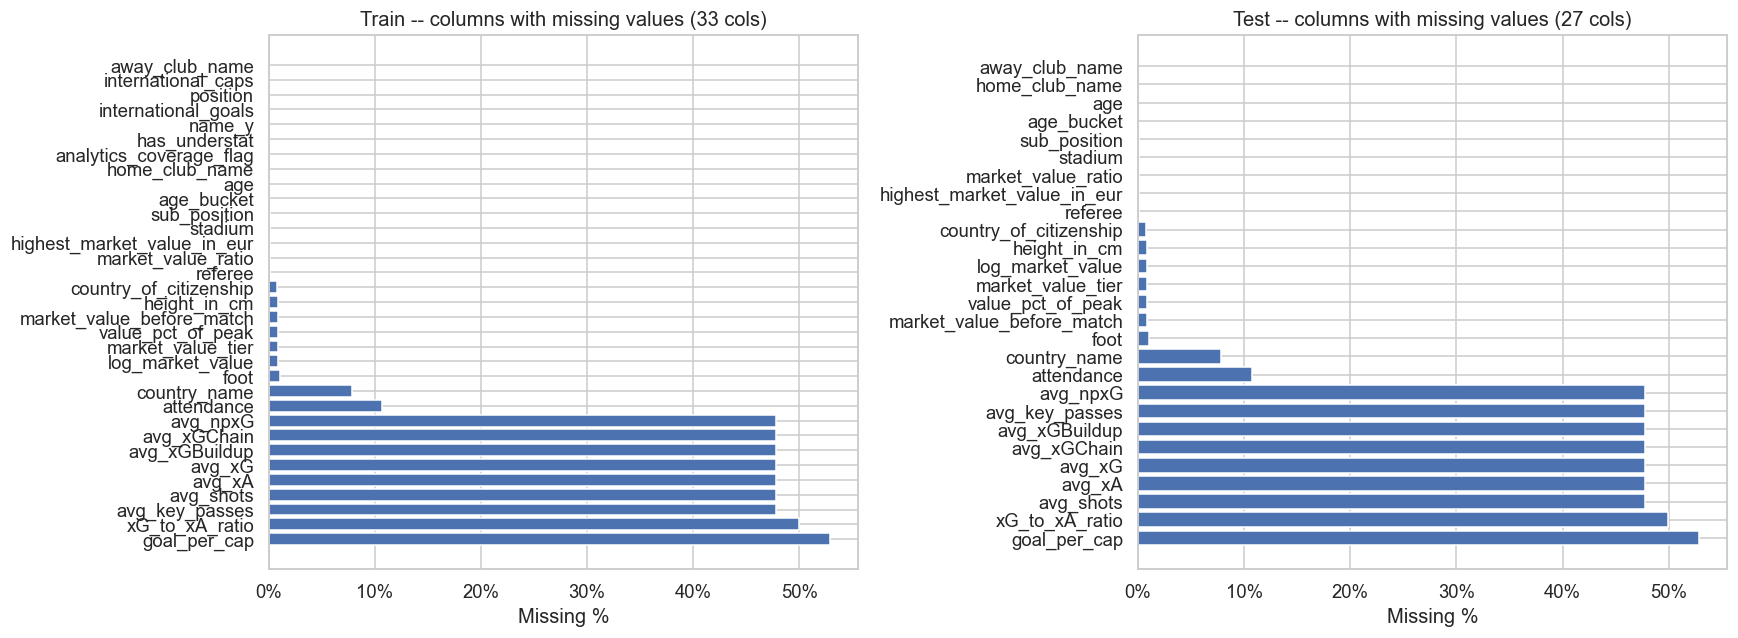

Top 10 missing columns (train):
goal_per_cap      52.9
xG_to_xA_ratio    50.0
avg_key_passes    47.8
avg_shots         47.8
avg_xA            47.8
avg_xG            47.8
avg_xGBuildup     47.8
avg_xGChain       47.8
avg_npxG          47.8
attendance        10.7


In [3]:
# Missingness heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df, title in zip(axes, [train, test], ["Train", "Test"]):
    miss = df.isnull().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    ax.barh(miss.index, miss.values * 100, color="#4C72B0")
    ax.set_xlabel("Missing %")
    ax.set_title(f"{title} -- columns with missing values ({len(miss)} cols)")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()

print("Top 10 missing columns (train):")
print((train.isnull().mean()*100).sort_values(ascending=False).head(10).round(1).to_string())

In [4]:
# Two key column groups
understat_cols = [c for c in train.columns if c.startswith("avg_")]
identity_cols  = [ID, "player_id_x", "home_club_id", "away_club_id", "game_id_x",
                  "home_club_name", "away_club_name", "referee", "stadium"]
numeric_cols   = train.select_dtypes(include=[np.number]).columns.tolist()
print(f"Understat analytics columns:  {understat_cols}")
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols[:15]} ...")

Understat analytics columns:  ['avg_xG', 'avg_xA', 'avg_shots', 'avg_key_passes', 'avg_xGChain', 'avg_xGBuildup', 'avg_npxG']

Numeric columns (30): ['season', 'minutes_played', 'yellow_cards', 'red_cards', 'disciplinary_points', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'attendance', 'market_value_before_match', 'age', 'height_in_cm', 'international_caps', 'international_goals'] ...


## 3. Target Variable -- Distribution & Class Imbalance

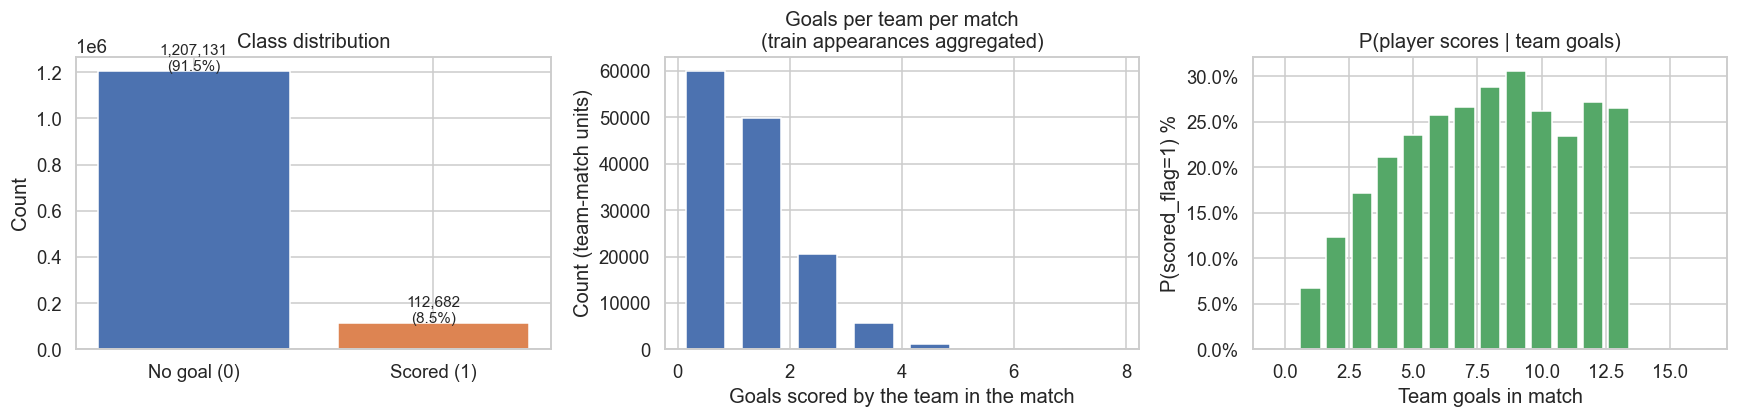

Positive rate by team goals:
team_goals_tmp
0      0.01
1      6.76
2     12.39
3     17.22
4     21.08
5     23.56
6     25.70
7     26.58
8     28.83
9     30.61
10    26.16
11    23.48
12    27.12
13    26.47
14     0.00
15     0.00
16     0.00


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class balance
axes[0].bar(["No goal (0)", "Scored (1)"], [y.value_counts()[0], y.value_counts()[1]],
            color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, [y.value_counts()[0], y.value_counts()[1]]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                 f"{val:,}\n({val/len(y)*100:.1f}%)", ha="center", fontsize=10)

# Goals per match (team level)
goals = train.groupby([train[ID].str.split("_").str[0], "home_away"])["scored_flag"].sum()
axes[1].hist(goals.values, bins=range(0,9), rwidth=0.7, color="#4C72B0", edgecolor="white")
axes[1].set_title("Goals per team per match\n(train appearances aggregated)")
axes[1].set_xlabel("Goals scored by the team in the match")
axes[1].set_ylabel("Count (team-match units)")

# Scoring rate by number of team goals
train["team_goals_tmp"] = np.where(train["home_away"]=="HOME",
    train["home_club_goals"], train["away_club_goals"])
rate = train.groupby("team_goals_tmp")[TARGET].mean()
axes[2].bar(rate.index, rate.values*100, color="#55A868", edgecolor="white")
axes[2].set_title("P(player scores | team goals)")
axes[2].set_xlabel("Team goals in match")
axes[2].set_ylabel("P(scored_flag=1) %")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout(); plt.show()
print("Positive rate by team goals:")
print((rate*100).round(2).to_string())
train.drop(columns=["team_goals_tmp"], inplace=True)

## 4. The Dominant Feature: `team_goals`

> **Key insight:** If a team scores 0 goals, the probability that any individual player scored
> is essentially zero (P ≈ 0.0001). This is a hard logical gate -- not a soft correlation.
> `team_goals` is the single most important feature by a wide margin.


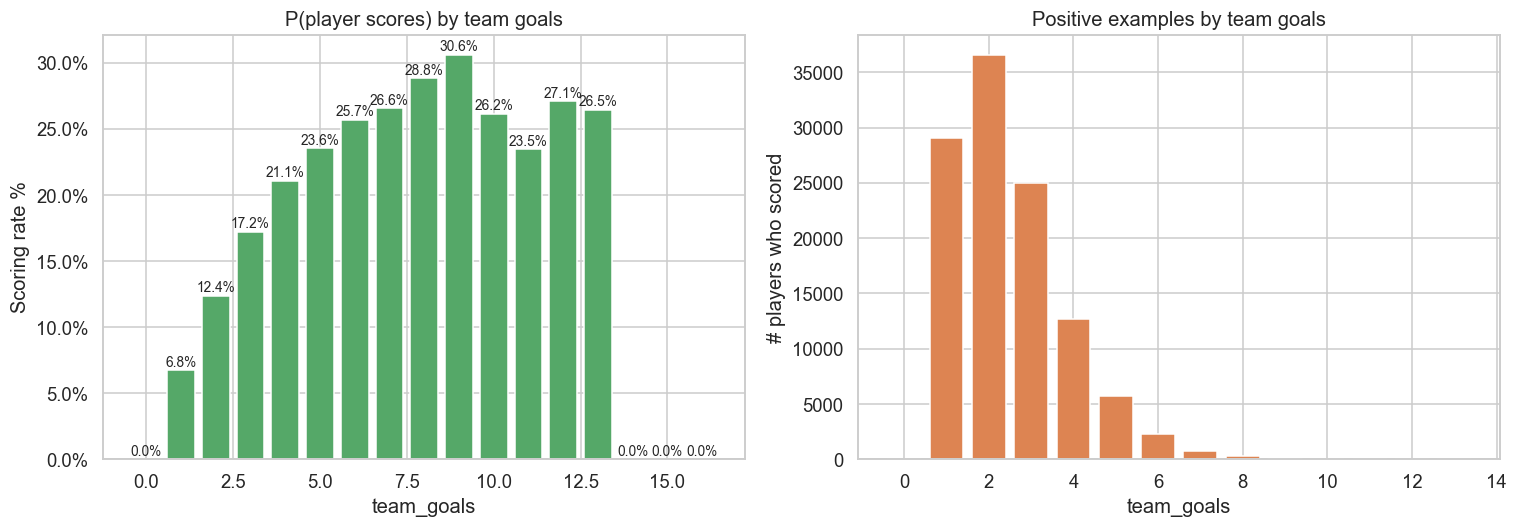

Positives when team_goals=0: 34 (0.0302% of all positives)
=> Applying team_goals=0 floor (set pred to ~0) on test predictions is lossless.


In [6]:
train["team_goals"] = np.where(train["home_away"]=="HOME",
    train["home_club_goals"], train["away_club_goals"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scoring rate conditional on team goals
rate = train.groupby("team_goals")[TARGET].agg(["mean","count"])
axes[0].bar(rate.index, rate["mean"]*100, color="#55A868", edgecolor="white")
axes[0].set_title("P(player scores) by team goals")
axes[0].set_xlabel("team_goals")
axes[0].set_ylabel("Scoring rate %")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (idx, row) in enumerate(rate.iterrows()):
    axes[0].text(idx, row["mean"]*100+0.3, f"{row['mean']*100:.1f}%", ha="center", fontsize=9)

# Cumulative: how many positives come from matches with >=1 team goal?
pos_by_tg = train[train[TARGET]==1].groupby("team_goals").size()
axes[1].bar(pos_by_tg.index, pos_by_tg.values, color="#DD8452", edgecolor="white")
axes[1].set_title("Positive examples by team goals")
axes[1].set_xlabel("team_goals")
axes[1].set_ylabel("# players who scored")

plt.tight_layout(); plt.show()

zero_goal_positives = train[(train["team_goals"]==0) & (train[TARGET]==1)].shape[0]
print(f"Positives when team_goals=0: {zero_goal_positives} ({zero_goal_positives/y.sum()*100:.4f}% of all positives)")
print(f"=> Applying team_goals=0 floor (set pred to ~0) on test predictions is lossless.")

## 5. Player Role & Position Analysis

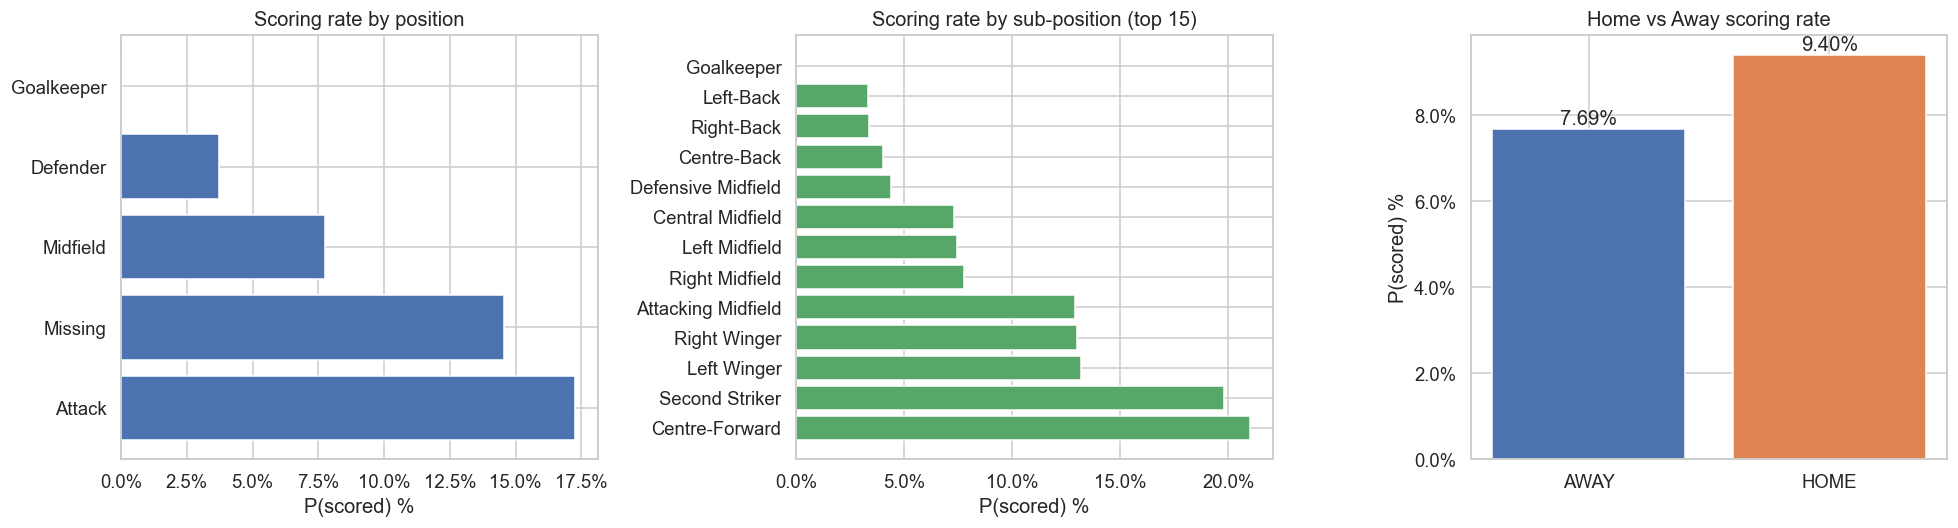

Scoring rate by position:
position
Attack        17.27
Missing       14.56
Midfield       7.75
Defender       3.72
Goalkeeper     0.02


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scoring rate by position
pos_rate = train.groupby("position")[TARGET].agg(["mean","count"]).sort_values("mean", ascending=False)
pos_rate = pos_rate[pos_rate["count"] > 1000]
axes[0].barh(pos_rate.index, pos_rate["mean"]*100, color="#4C72B0")
axes[0].set_title("Scoring rate by position")
axes[0].set_xlabel("P(scored) %")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())

# Scoring rate by sub_position
sub_rate = train.groupby("sub_position")[TARGET].agg(["mean","count"]).sort_values("mean", ascending=False)
sub_rate = sub_rate[sub_rate["count"] > 500].head(15)
axes[1].barh(sub_rate.index, sub_rate["mean"]*100, color="#55A868")
axes[1].set_title("Scoring rate by sub-position (top 15)")
axes[1].set_xlabel("P(scored) %")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

# Scoring rate by home/away
ha_rate = train.groupby("home_away")[TARGET].mean()
axes[2].bar(ha_rate.index, ha_rate.values*100, color=["#4C72B0","#DD8452"])
axes[2].set_title("Home vs Away scoring rate")
axes[2].set_ylabel("P(scored) %")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(axes[2].patches, ha_rate.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, val*100+0.1, f"{val*100:.2f}%", ha="center")

plt.tight_layout(); plt.show()

print("Scoring rate by position:")
print((pos_rate["mean"]*100).round(2).to_string())

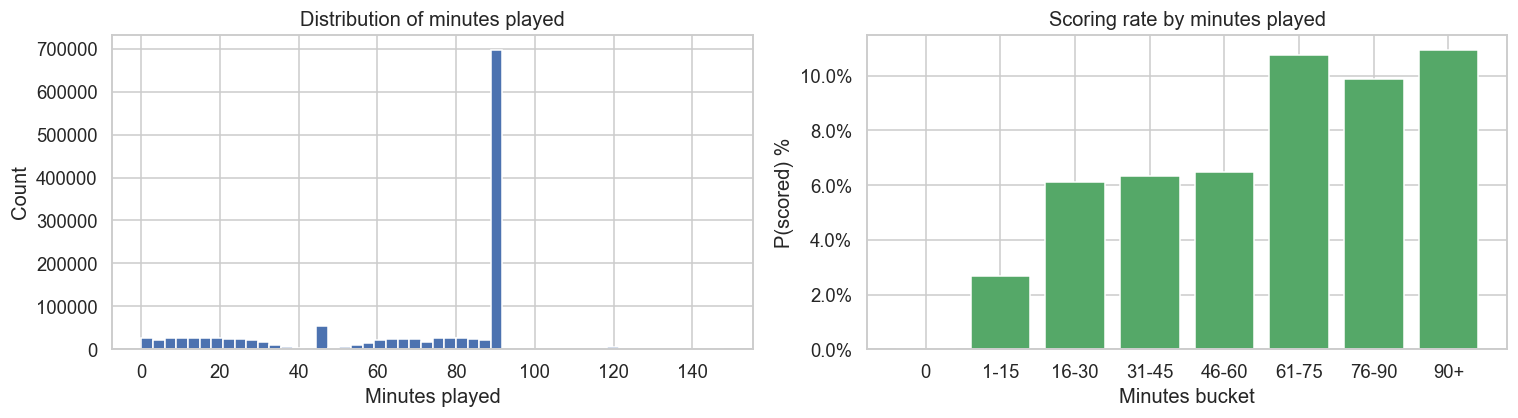

Players with 0 minutes: 16 (0.0%)
Their scoring rate:     0.000%


In [8]:
# Minutes played
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of minutes played
axes[0].hist(train["minutes_played"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of minutes played")
axes[0].set_xlabel("Minutes played"); axes[0].set_ylabel("Count")

# Scoring rate by minutes bins
train["min_bin"] = pd.cut(train["minutes_played"],
    bins=[-1,0,15,30,45,60,75,90,200], labels=["0","1-15","16-30","31-45","46-60","61-75","76-90","90+"])
min_rate = train.groupby("min_bin", observed=True)[TARGET].mean()
axes[1].bar(min_rate.index.astype(str), min_rate.values*100, color="#55A868", edgecolor="white")
axes[1].set_title("Scoring rate by minutes played")
axes[1].set_xlabel("Minutes bucket"); axes[1].set_ylabel("P(scored) %")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout(); plt.show()
train.drop(columns=["min_bin"], inplace=True)
print(f"Players with 0 minutes: {(train['minutes_played']==0).sum():,} ({(train['minutes_played']==0).mean()*100:.1f}%)")
print(f"Their scoring rate:     {train[train['minutes_played']==0][TARGET].mean()*100:.3f}%")

## 6. Understat Analytics Coverage (xG, shots, xA)

Understat data is missing for many appearances (lower leagues, older seasons).
The **presence** of Understat data is itself predictive -- it correlates with leagues/seasons
where goal-scoring patterns differ.


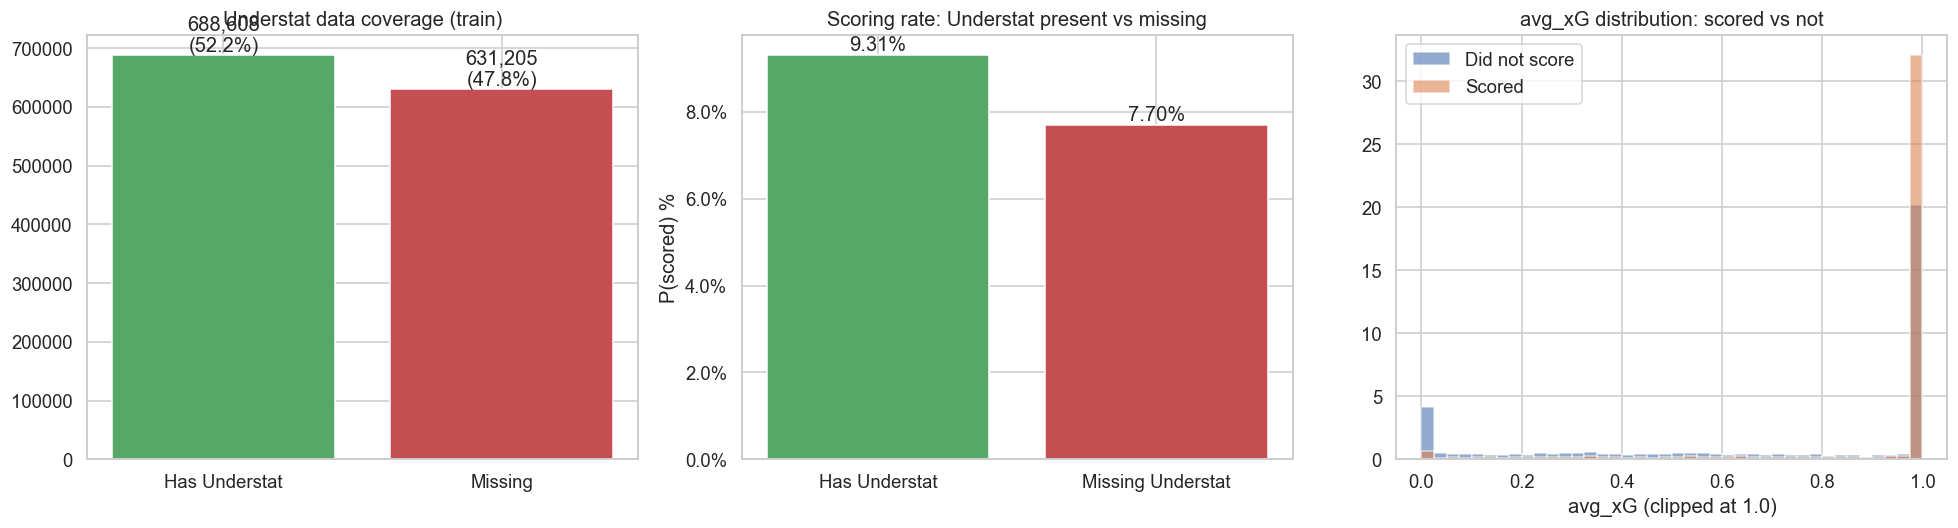

Median avg_xG | scored:     2.8832
Median avg_xG | not scored: 0.9891


In [9]:
understat_miss = train["avg_xG"].isna()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Coverage rate
axes[0].bar(["Has Understat", "Missing"],
            [(~understat_miss).sum(), understat_miss.sum()],
            color=["#55A868", "#C44E52"])
axes[0].set_title("Understat data coverage (train)")
for bar, val in zip(axes[0].patches, [(~understat_miss).sum(), understat_miss.sum()]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
                 f"{val:,}\n({val/len(train)*100:.1f}%)", ha="center")

# Scoring rate with vs without Understat
rates = train.groupby(understat_miss)[TARGET].mean()
axes[1].bar(["Has Understat", "Missing Understat"],
            [rates[False]*100, rates[True]*100],
            color=["#55A868", "#C44E52"])
axes[1].set_title("Scoring rate: Understat present vs missing")
axes[1].set_ylabel("P(scored) %")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(axes[1].patches, [rates[False]*100, rates[True]*100]):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.1, f"{val:.2f}%", ha="center")

# xG distribution for scorers vs non-scorers
scored    = train[(train[TARGET]==1) & (~understat_miss)]["avg_xG"]
not_scored= train[(train[TARGET]==0) & (~understat_miss)]["avg_xG"]
axes[2].hist(not_scored.clip(0,1), bins=40, alpha=0.6, density=True, label="Did not score", color="#4C72B0")
axes[2].hist(scored.clip(0,1),     bins=40, alpha=0.6, density=True, label="Scored",        color="#DD8452")
axes[2].set_title("avg_xG distribution: scored vs not")
axes[2].set_xlabel("avg_xG (clipped at 1.0)"); axes[2].legend()

plt.tight_layout(); plt.show()
print(f"Median avg_xG | scored:     {scored.median():.4f}")
print(f"Median avg_xG | not scored: {not_scored.median():.4f}")

In [10]:
# xG correlation with scoring outcome
from sklearn.metrics import average_precision_score
xg_ap = average_precision_score(
    train[~understat_miss][TARGET],
    train[~understat_miss]["avg_xG"].fillna(0)
)
tg_ap = average_precision_score(train[TARGET], train["team_goals"])

print(f"AP of avg_xG alone (Understat subset):  {xg_ap:.4f}")
print(f"AP of team_goals alone (full train):    {tg_ap:.4f}")
print(f"\nInference: team_goals is a stronger individual predictor than xG alone,")
print(f"because it captures the actual match outcome context, not just pre-match expectation.")

AP of avg_xG alone (Understat subset):  0.2290
AP of team_goals alone (full train):    0.1696

Inference: team_goals is a stronger individual predictor than xG alone,
because it captures the actual match outcome context, not just pre-match expectation.


## 7. Market Value & Player Tier Analysis

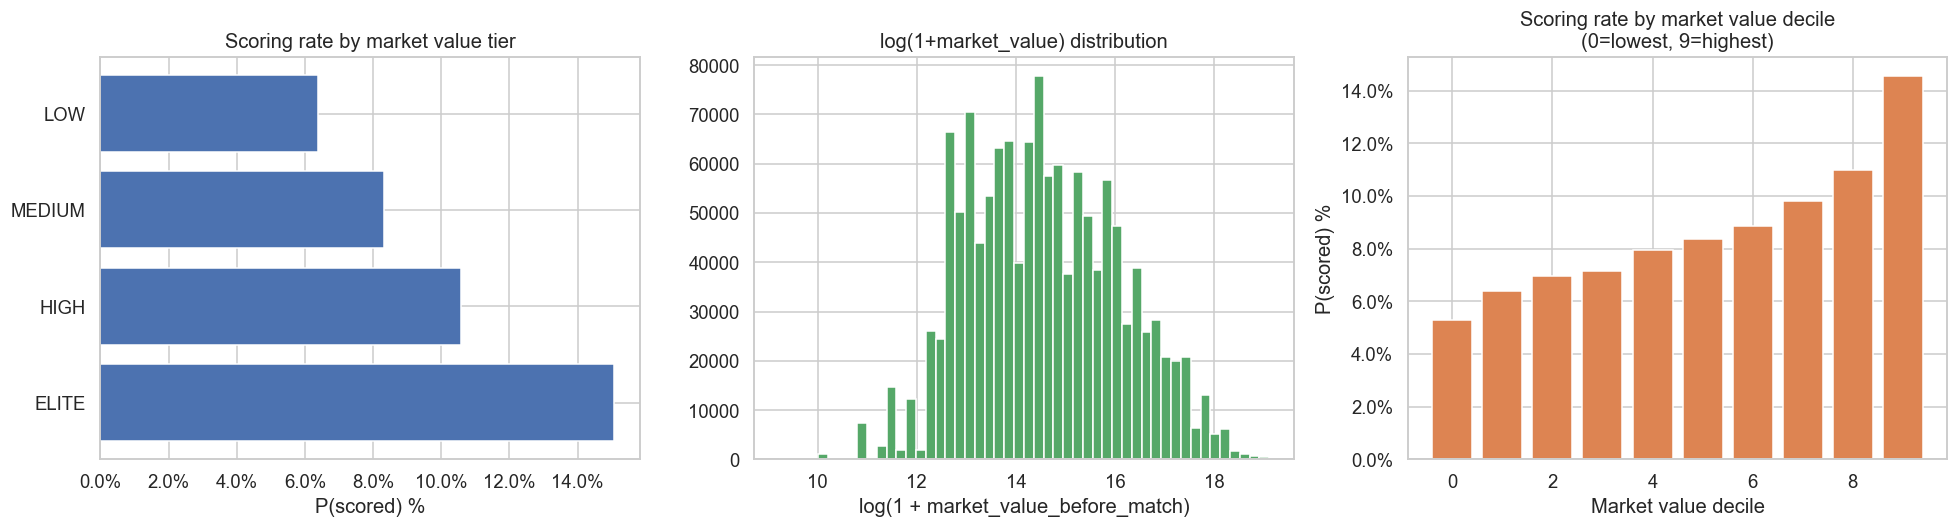

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scoring rate by market value tier
if "market_value_tier" in train.columns:
    tier_rate = train.groupby("market_value_tier")[TARGET].agg(["mean","count"])
    tier_rate = tier_rate[tier_rate["count"] > 500].sort_values("mean", ascending=False)
    axes[0].barh(tier_rate.index.astype(str), tier_rate["mean"]*100, color="#4C72B0")
    axes[0].set_title("Scoring rate by market value tier")
    axes[0].set_xlabel("P(scored) %")
    axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())

# Market value distribution
mv = train["market_value_before_match"].dropna()
axes[1].hist(np.log1p(mv), bins=50, color="#55A868", edgecolor="white")
axes[1].set_title("log(1+market_value) distribution")
axes[1].set_xlabel("log(1 + market_value_before_match)")

# Scoring rate by log-MV quantile
train["mv_q"] = pd.qcut(train["market_value_before_match"].fillna(0), q=10, labels=False, duplicates="drop")
mvq_rate = train.groupby("mv_q")[TARGET].mean()
axes[2].bar(mvq_rate.index, mvq_rate.values*100, color="#DD8452", edgecolor="white")
axes[2].set_title("Scoring rate by market value decile\n(0=lowest, 9=highest)")
axes[2].set_xlabel("Market value decile")
axes[2].set_ylabel("P(scored) %")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout(); plt.show()
train.drop(columns=["mv_q"], inplace=True)

## 8. Temporal Patterns -- Season, Month, Day-of-Week

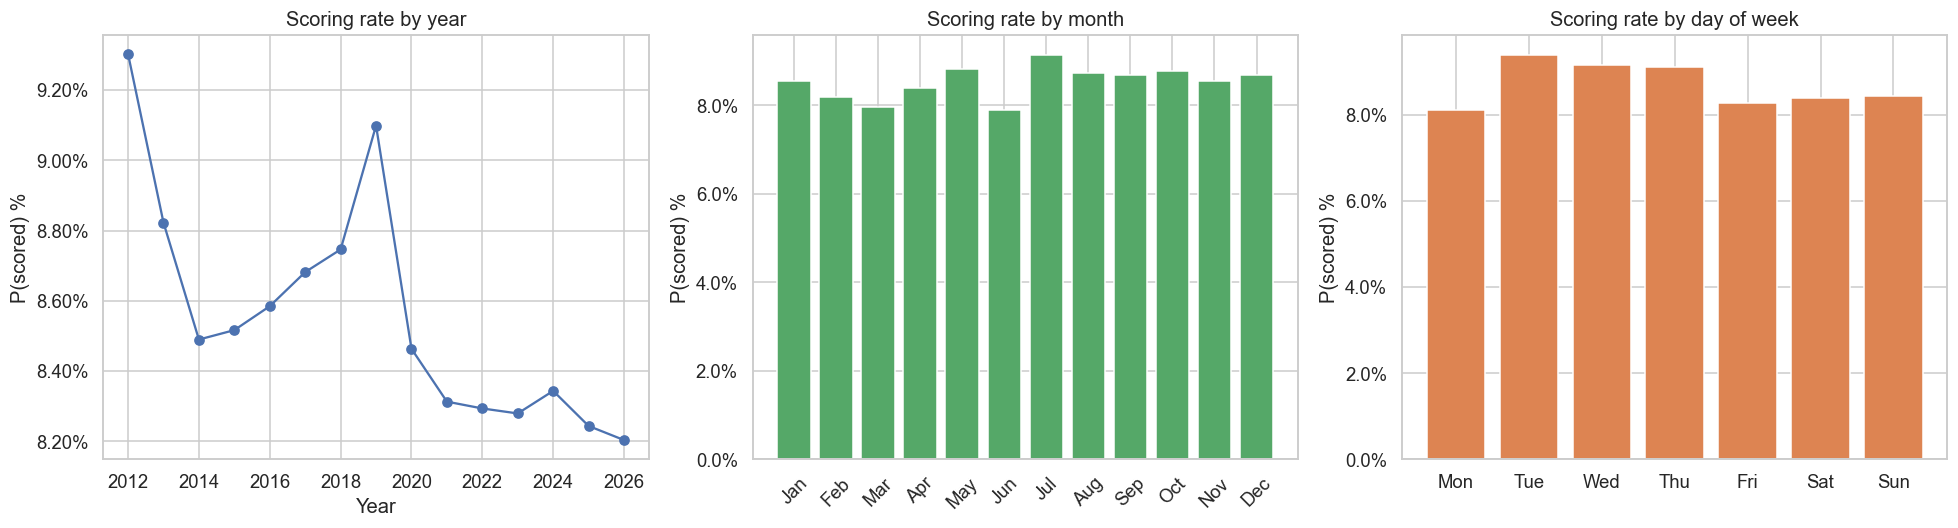

Season range in train: 2012 - 2026
Season range in test:  2012 - 2026


In [12]:
train["date_dt"]    = pd.to_datetime(train["date"], errors="coerce")
train["month"]      = train["date_dt"].dt.month
train["dayofweek"]  = train["date_dt"].dt.dayofweek
train["year"]       = train["date_dt"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scoring rate by season/year
yr_rate = train.groupby("year")[TARGET].agg(["mean","count"])
yr_rate = yr_rate[yr_rate["count"] > 10000]
axes[0].plot(yr_rate.index, yr_rate["mean"]*100, marker="o", color="#4C72B0")
axes[0].set_title("Scoring rate by year")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("P(scored) %")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# By month
mon_rate = train.groupby("month")[TARGET].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar(range(1,13), mon_rate.values*100, color="#55A868", edgecolor="white")
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title("Scoring rate by month")
axes[1].set_ylabel("P(scored) %")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# By day of week
day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_rate = train.groupby("dayofweek")[TARGET].mean()
axes[2].bar(day_names, dow_rate.values*100, color="#DD8452", edgecolor="white")
axes[2].set_title("Scoring rate by day of week")
axes[2].set_ylabel("P(scored) %")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout(); plt.show()

print(f"Season range in train: {int(train['year'].min())} - {int(train['year'].max())}")
print(f"Season range in test:  {int(pd.to_datetime(test['date'],errors='coerce').dt.year.min())} - "
      f"{int(pd.to_datetime(test['date'],errors='coerce').dt.year.max())}")

## 9. Competition & Geography

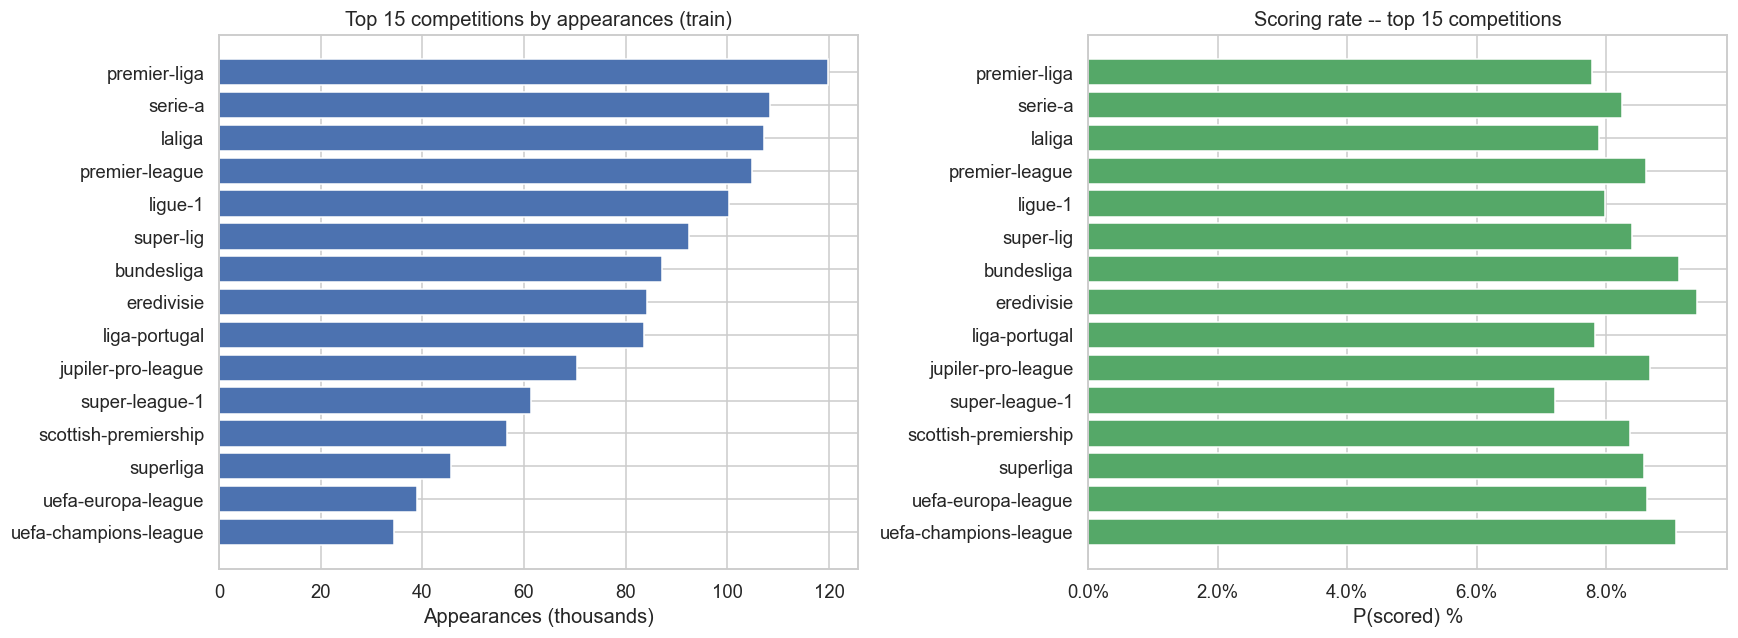

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top competitions by appearance count
comp_rate = train.groupby("name_x")[TARGET].agg(["mean","count"]).sort_values("count", ascending=False).head(15)
axes[0].barh(comp_rate.index[::-1], comp_rate["count"][::-1]/1000, color="#4C72B0")
axes[0].set_title("Top 15 competitions by appearances (train)")
axes[0].set_xlabel("Appearances (thousands)")

# Scoring rate per competition (top 15 by volume)
axes[1].barh(comp_rate.index[::-1], comp_rate["mean"][::-1]*100, color="#55A868")
axes[1].set_title("Scoring rate -- top 15 competitions")
axes[1].set_xlabel("P(scored) %")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout(); plt.show()

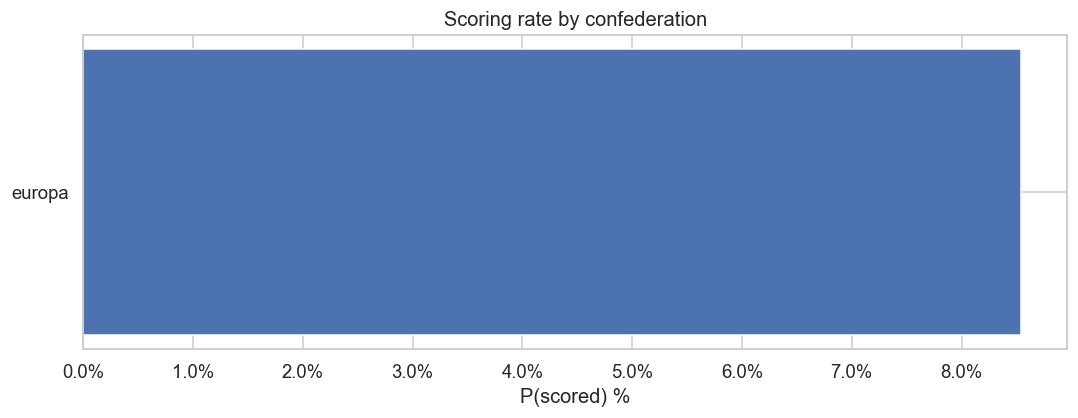

In [14]:
# Confederation
if "confederation" in train.columns:
    conf_rate = train.groupby("confederation")[TARGET].agg(["mean","count"]).sort_values("mean", ascending=False)
    conf_rate = conf_rate[conf_rate["count"] > 1000]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(conf_rate.index, conf_rate["mean"]*100, color="#4C72B0")
    ax.set_title("Scoring rate by confederation")
    ax.set_xlabel("P(scored) %")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout(); plt.show()

## 10. Train / Test Overlap -- The Random Split Insight

This is critical for understanding why certain features work and how to validate correctly.


In [15]:
# Parse IDs
train["game_id_p"]   = train[ID].str.split("_").str[0]
train["player_id_p"] = train[ID].str.split("_").str[1]
test["game_id_p"]    = test[ID].str.split("_").str[0]
test["player_id_p"]  = test[ID].str.split("_").str[1]

shared_games   = set(train["game_id_p"]) & set(test["game_id_p"])
shared_players = set(train["player_id_p"]) & set(test["player_id_p"])
tr_seasons     = set(train["season"].dropna().unique())
te_seasons     = set(test["season"].dropna().unique())

print(f"Unique games   -- train: {train['game_id_p'].nunique():,}  |  test: {test['game_id_p'].nunique():,}")
print(f"Shared games:    {len(shared_games):,}  ({len(shared_games)/test['game_id_p'].nunique()*100:.1f}% of test games)")
print(f"\nUnique players -- train: {train['player_id_p'].nunique():,}  |  test: {test['player_id_p'].nunique():,}")
print(f"Shared players:  {len(shared_players):,}  ({len(shared_players)/test['player_id_p'].nunique()*100:.1f}% of test players)")
print(f"\nSeason overlap -- train: {sorted(tr_seasons)[:3]}...{sorted(tr_seasons)[-3:]}")
print(f"               -- test:  {sorted(te_seasons)[:3]}...{sorted(te_seasons)[-3:]}")
print(f"Seasons in BOTH: {len(tr_seasons & te_seasons)}")

print(
    "\n=> The split is RANDOM (not temporal). Train and test share the same:\n"
    "   - Season range (2012-2026)\n"
    "   - Games (different players from same match appear in different splits)\n"
    "   - Players (same player appears in multiple matches, some in train, some in test)\n\n"
    "=> Correct validation: StratifiedKFold(5) -- NOT time-based splitting.\n"
    "=> Group target encoding (te_game_team_id) is VALID because test rows from the\n"
    "   same team-match are encoded using training appearances from OTHER folds.\n"
)
train.drop(columns=["game_id_p","player_id_p"], inplace=True)
test.drop(columns=["game_id_p","player_id_p"], inplace=True)

Unique games   -- train: 72,366  |  test: 70,728
Shared games:    69,854  (98.8% of test games)

Unique players -- train: 27,862  |  test: 25,348
Shared players:  24,487  (96.6% of test players)

Season overlap -- train: [np.int64(2012), np.int64(2013), np.int64(2014)]...[np.int64(2023), np.int64(2024), np.int64(2025)]
               -- test:  [np.int64(2012), np.int64(2013), np.int64(2014)]...[np.int64(2023), np.int64(2024), np.int64(2025)]
Seasons in BOTH: 14

=> The split is RANDOM (not temporal). Train and test share the same:
   - Season range (2012-2026)
   - Games (different players from same match appear in different splits)
   - Players (same player appears in multiple matches, some in train, some in test)

=> Correct validation: StratifiedKFold(5) -- NOT time-based splitting.
=> Group target encoding (te_game_team_id) is VALID because test rows from the
   same team-match are encoded using training appearances from OTHER folds.



## 11. Correlation & Feature Relationships

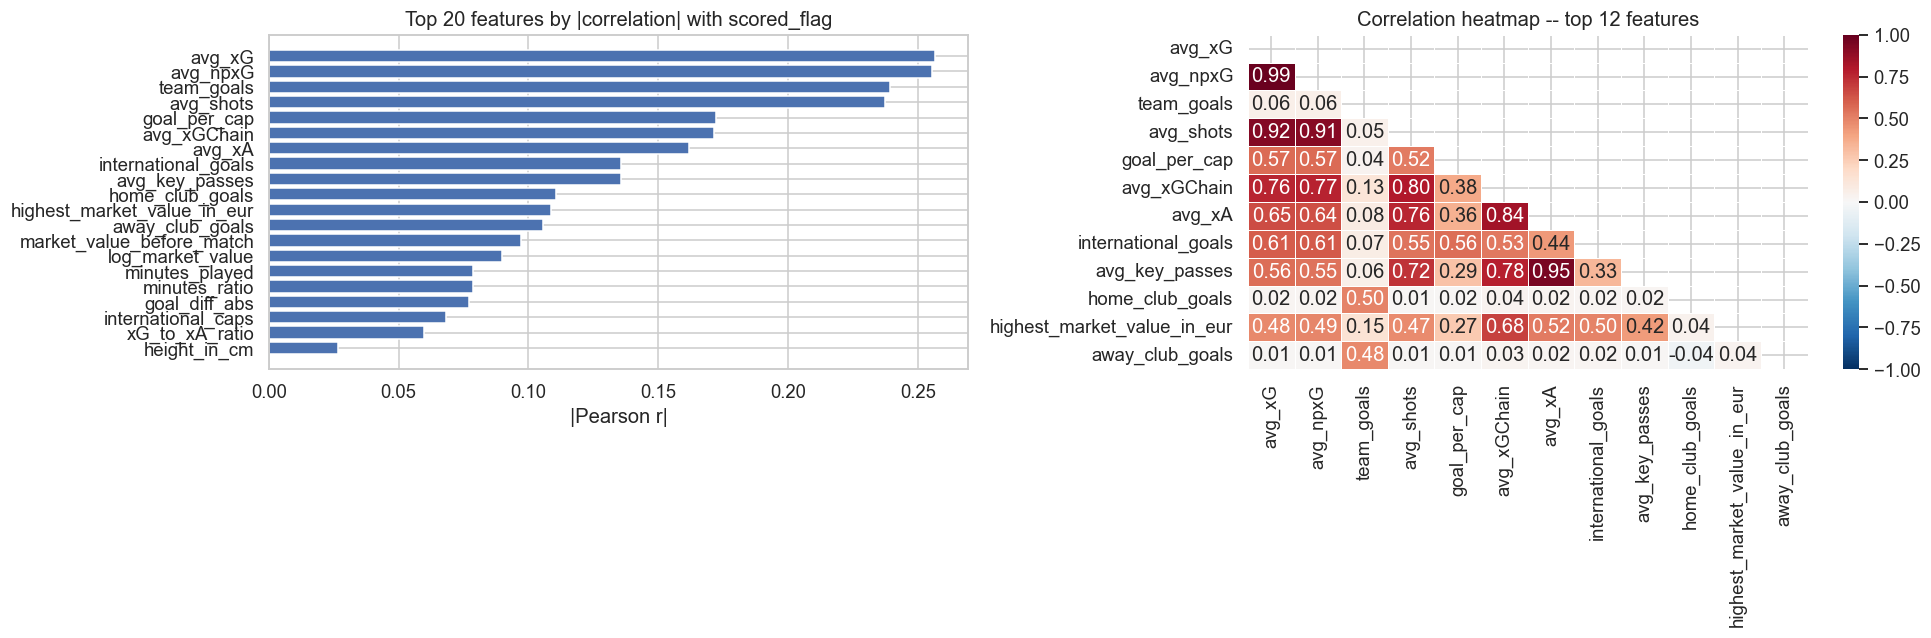

Top 10 features by |correlation| with target:
avg_xG                 0.2565
avg_npxG               0.2555
team_goals             0.2391
avg_shots              0.2372
goal_per_cap           0.1722
avg_xGChain            0.1713
avg_xA                 0.1620
international_goals    0.1358
avg_key_passes         0.1357
home_club_goals        0.1105


In [16]:
numeric = train.select_dtypes(include=[np.number]).copy()
numeric = numeric.drop(columns=[TARGET], errors="ignore")

# Correlation with target
target_corr = numeric.corrwith(y).abs().sort_values(ascending=False).dropna()
top20 = target_corr.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].barh(top20.index[::-1], top20.values[::-1], color="#4C72B0")
axes[0].set_title("Top 20 features by |correlation| with scored_flag")
axes[0].set_xlabel("|Pearson r|")

# Correlation heatmap of top features
top_feats = target_corr.head(12).index.tolist()
corr_mat  = numeric[top_feats].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, ax=axes[1], cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title("Correlation heatmap -- top 12 features")

plt.tight_layout(); plt.show()

print("Top 10 features by |correlation| with target:")
print(top20.head(10).round(4).to_string())

In [ ]:
# Pairplot for the most important numeric features
key_feats = ["team_goals", "minutes_played", "avg_xG", "market_value_before_match",
             "home_club_goals", "away_club_goals"]
key_feats = [f for f in key_feats if f in train.columns]

sample = train[key_feats + [TARGET]].dropna().sample(min(5000, len(train)), random_state=42)
sample[TARGET] = sample[TARGET].astype(int).astype(str)  # ensures "0"/"1" regardless of bool/int dtype

g = sns.pairplot(sample, hue=TARGET, plot_kws={"alpha":0.3, "s":10},
                 vars=key_feats, palette={"0":"#4C72B0","1":"#DD8452"})
g.fig.suptitle("Pairplot -- key features coloured by scored_flag", y=1.02)
plt.tight_layout(); plt.show()

## 12. Key Inferences & Competition Strategy

### What the data tells us

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **`team_goals` is a near-perfect gate.** P(score \| team_goals=0) ≈ 0.0001. | Apply monotone constraint on this feature; set predictions to ~0 when team scored 0. |
| 2 | **Split is random, not temporal.** Train and test share the same seasons, games, and players. | Use `StratifiedKFold`, not time-series CV. Group target encoding is valid and not leakage. |
| 3 | **Understat missingness is itself signal.** Missing xG rows have a different scoring rate than those with data. | Do NOT impute -- leave NaN as NaN; tree models exploit it as a split point. |
| 4 | **Player position matters a lot.** Forwards score ~4×-5× more often than defenders/goalkeepers. | Sub-position and position are important categorical features. |
| 5 | **`te_game_team_id` is the biggest engineered lever.** It encodes team scoring density per game. | OOF target encoding at the team×game grain adds ~+0.031 AP over baseline. |
| 6 | **Home advantage exists but is small.** Home players score ~1-2% more often. | Include `home_away` as a feature; don't over-index on it. |
| 7 | **xG has moderate predictive power alone (AP ≈ 0.17 on Understat subset).** | xG is useful but incomplete -- it measures opportunity, not outcome. |
| 8 | **Blending LGB + CatBoost outperforms any single model.** | Ensemble; the two models make uncorrelated errors at the margin. |

### What did NOT help (empirically tested)
- SMOTE / undersampling / class weights -- neutral-to-negative for AP (ranking metric)
- MissForest imputation / StandardScaler / outlier removal -- all neutral-to-negative
- Explicit feature interactions (xG×team_goals, etc.) -- GBMs learn them via splits
- OOF stacking -- neutral (base models too correlated)
- Dropping correlated features -- slightly negative (correlated features still add information)

### Best model summary
| Component | Value |
|-----------|-------|
| OOF AP (blend) | **0.52111** (6.1× random baseline) |
| OOF AUC | 0.91822 |
| Blend weights | 0.60 × LightGBM + 0.40 × CatBoost |
| Validation | StratifiedKFold(5, seed=42) |
| Key feature | `te_game_team_id` (OOF group target encoding) |
| #2 feature | `team_goals` (monotone constraint applied) |
